In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import subprocess as sub
import time
from scipy.optimize import differential_evolution
from scipy.optimize import Bounds
from matplotlib import colors
from sklearn.neighbors import NearestNeighbors
#plt.style.use('seaborn-v0_8-whitegrid')
plt.style.use('default')
G = 6.6742e-8
C = 2.99792458e10
Msun = 1.9891e33

In [11]:
N_spins = 12
N_dens = 20
r_ratios = np.log10(np.linspace(9.9, 6, N_spins))
eoss = np.array(pd.read_csv('compose/max_dens.csv', header=None))
eos_names = eoss[:,0]
min_dens = eoss[:,1]
max_dens = eoss[:,2]

Obects that store neutron star data for each EoS

In [3]:
class Eos_Set():

    def __init__(self, eos_name):

        self.name = eos_name
        self.data = np.load("star_data_"+eos_name+'.npy')
    
    def filter_index(self, i_r):

        massrange = np.array([0.9, 2.4])*Msun
        spinrange = 900*2*np.pi
        mrrange = np.array([0.05, 1])

        indices = np.where(
        (self.data[:, i_r, 3] > massrange[0]) & 
        (self.data[:, i_r, 3] < massrange[1]) & 
        (self.data[:, i_r, 1] < spinrange) & 
        (self.data[:, i_r, 4] > mrrange[0]) &
        (self.data[:, i_r, 4] < mrrange[1])
        )[0]
        indices = np.unique(indices)
        indices.sort()
        return indices.astype(int)
        
    def MR(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 4]

    def SPN(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 5]

    def z_rns(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 6]

    def quad(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 7]

    def J(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 8]
    
    def z_qfit(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 11]
    
    def M(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 3]/Msun
    
    def f(self, i_r):

        return self.data[self.filter_index(i_r), i_r, 1]/(2*np.pi)

Arrays that store these objects

In [4]:
Eos_array = np.empty(eos_names.size, dtype=object)

for k in range(eos_names.size):

    Eos_array[k] = Eos_Set(eos_names[k])

Nreal = np.where(eos_names == 'Pol0')[0][0]
Eos_real = np.empty(Nreal, dtype=object)

for k in range(Nreal):

    Eos_real[k] = Eos_Set(eos_names[k])

Eos_poly = np.empty(10, dtype=object)

for k in range(10):

    Eos_poly[k] = Eos_Set(eos_names[k+Nreal])

------------------
Quadrupole moment fits

In [ ]:
def create_fit_func_q(shapes):

    def general_fit(M_R, spins, params):

        # m is for MR
        # n is for Omega

        params = np.array(params).reshape(shapes)
        print(params)
        n = shapes[0]
        m = shapes[1]

        fit = np.zeros(M_R.shape)
        for i in range(n):
            for j in range(m):
                #print(str(params[i,j])+" M/R^"+str(j+1)+" omega^"+str(2*(i+1)))
                fit += params[i,j]*M_R**(-j)*spins**(2*(i))
        
        return fit

    return general_fit

In [7]:
def fractional_fit(M_R, spins, params):

    fit = np.zeros(M_R.shape)
    fit += params[0]
    fit += params[1]*M_R**params[2]
    fit += params[3]*spins**params[4]
    fit += params[5]*M_R**params[6]*spins**params[7]

    return fit

In [8]:
def create_offset_fit(shapes):
    
    def offset_fit(M_R, spins, params):

        fit = np.zeros(M_R.shape)
        mr_off = params[0]

        params = np.array(params[1:]).reshape(shapes)
        n = shapes[0]
        m = shapes[1]

        fit = np.zeros(M_R.shape)
        for i in range(n):
            for j in range(m):
                #print(params[i,j], -j, 2*i)
                fit += params[i,j]*(M_R-mr_off)**(-(j))*spins**(2*(i))

        return fit

    return offset_fit

In [12]:
def residual_q(params, Eos_array, fit_func):

    M_R = np.empty([0])
    spins = np.empty([0])
    Js = np.empty([0])
    q_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            j = eos.J(i_r)
            q_norm_p = eos.quad(i_r)

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            Js = np.concatenate([Js, j])
            q_norm = np.concatenate([q_norm, q_norm_p])

    q_emp = fit_func(M_R, spins, params)
    resid = np.sum((q_norm-q_emp)**2)

    return resid

In [ ]:
def LSQ_fit_q(Eos_array, shapes):

    M_R = np.empty([0])
    spins = np.empty([0])
    q_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            q_norm_p = eos.quad(i_r)

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            q_norm = np.concatenate([q_norm, q_norm_p])

    n = shapes[0]
    m = shapes[1]

    X = ()
    for i in range(n):
        for j in range(m):
            X += ((M_R**(-j)*spins**(2*i)),)
    X = np.array(X).transpose()

    xT = np.transpose(X)
    xTx = np.dot(xT, X)
    xTxinv = np.linalg.inv(xTx)
    C = np.dot(xTxinv, xT)
    coefs = np.dot(C, q_norm)

    return coefs

In [14]:
shape1 = [6,5]
params = LSQ_fit_q(Eos_array, shape1)
#rows, cols = np.triu_indices(6)
#cols = 5 - cols
#matrix = np.zeros((6, 6))
#matrix[rows, cols] = params
print(repr(params))
residual_q(params, Eos_array, create_fit_func_q(shape1))

array([-4.40091439e+00,  3.08546616e+00, -8.19877533e-01,  8.72705045e-02,
       -3.34795070e-03,  9.97949558e+01, -7.72917118e+01,  2.07214036e+01,
       -2.26596707e+00,  8.85069606e-02, -1.00241955e+03,  8.08849865e+02,
       -2.21442267e+02,  2.44256873e+01, -9.56602442e-01,  4.45469073e+03,
       -3.76601621e+03,  1.05680595e+03, -1.17681070e+02,  4.62649387e+00,
       -9.12294091e+03,  8.10885539e+03, -2.33318766e+03,  2.62184489e+02,
       -1.03429609e+01,  6.85866703e+03, -6.52368039e+03,  1.93614855e+03,
       -2.20080898e+02,  8.72152037e+00])
[[-4.40091439e+00  3.08546616e+00 -8.19877533e-01  8.72705045e-02
  -3.34795070e-03]
 [ 9.97949558e+01 -7.72917118e+01  2.07214036e+01 -2.26596707e+00
   8.85069606e-02]
 [-1.00241955e+03  8.08849865e+02 -2.21442267e+02  2.44256873e+01
  -9.56602442e-01]
 [ 4.45469073e+03 -3.76601621e+03  1.05680595e+03 -1.17681070e+02
   4.62649387e+00]
 [-9.12294091e+03  8.10885539e+03 -2.33318766e+03  2.62184489e+02
  -1.03429609e+01]
 [ 6.858

25.269177422440247

In [13]:
def plot_3dquads(Eos_array, fit_func, params, savename, errors=False):

    fig = plt.figure(figsize=plt.figaspect(0.9)*2)
    ax = fig.add_subplot(projection='3d')

    M_R = np.empty([0])
    spins = np.empty([0])
    js = np.empty([0])
    q_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            j = eos.J(i_r)
            q_norm_p = (eos.quad(i_r))
            q_emp_p = fit_func(mr, spn, params)

            if errors:
                ax.scatter(mr, spn**2, (q_norm_p-q_emp_p)*100/q_emp_p, alpha=0.3, s=5, c='k')
            else:
                ax.scatter(mr, spn**2, q_norm_p, alpha=0.3, s=5, c='k')

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            js = np.concatenate([js, j])
            q_norm = np.concatenate([q_norm, q_norm_p])

    M_R_mesh, spins_mesh = np.meshgrid(np.sort(M_R), np.sort(spins))
    q_emp = fit_func(M_R_mesh, spins_mesh, params)

    if errors:
        ax.plot_surface(M_R_mesh, spins_mesh**2, np.zeros(M_R_mesh.shape), color='green', alpha=0.2)
    else:
        ax.plot_surface(M_R_mesh, spins_mesh**2, q_emp, color='green', alpha=0.2)
    ax.view_init(elev=10, azim=135)
    ax.set_box_aspect(aspect=(1, 1, 1))
    font=11
    ax.tick_params(labelsize=font, pad=1)
    ax.tick_params(axis='z', labelsize=font, pad=4)
    ax.set_xlabel("M/R", labelpad=2)
    ax.set_ylabel("$\overline{\Omega}^{\ 2}$", labelpad=2)
    if errors:
        ax.set_zlim([-30, 100])
        ax.set_zlabel(r"${\Delta q \ }/ \ q \cdot 100$", labelpad=8)
    else:
        ax.set_zlabel("$q$", labelpad=8)



    plt.savefig(savename+".png", dpi=390)

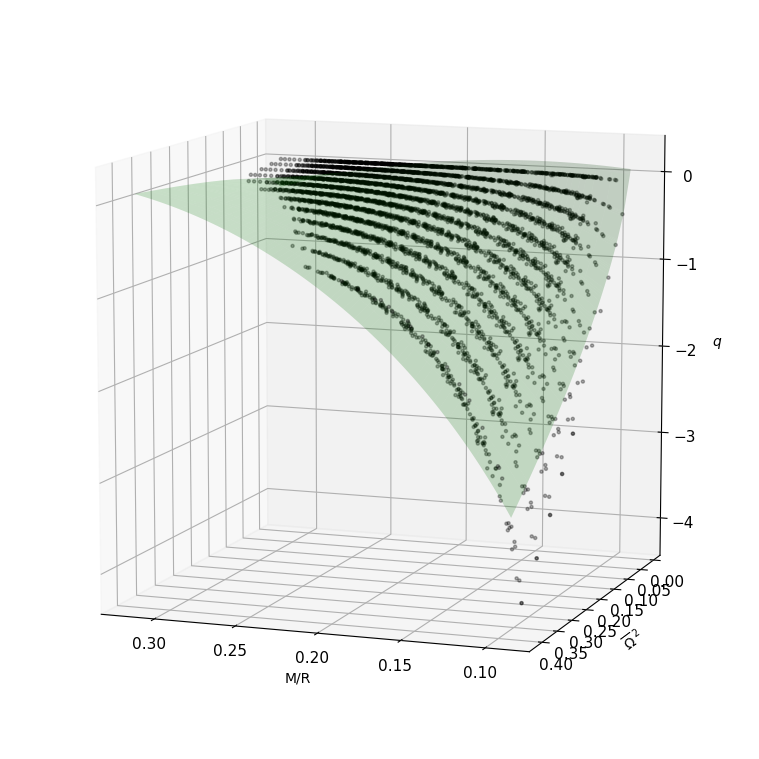

In [62]:
plot_3dquads(Eos_array, fractional_fit, [  0.28009222, -19.42319378,   2.9131121 , -57.02563778,
         1.16789637,  64.42014735,   0.095313  ,   1.16251014], "Q_fractional_fit")

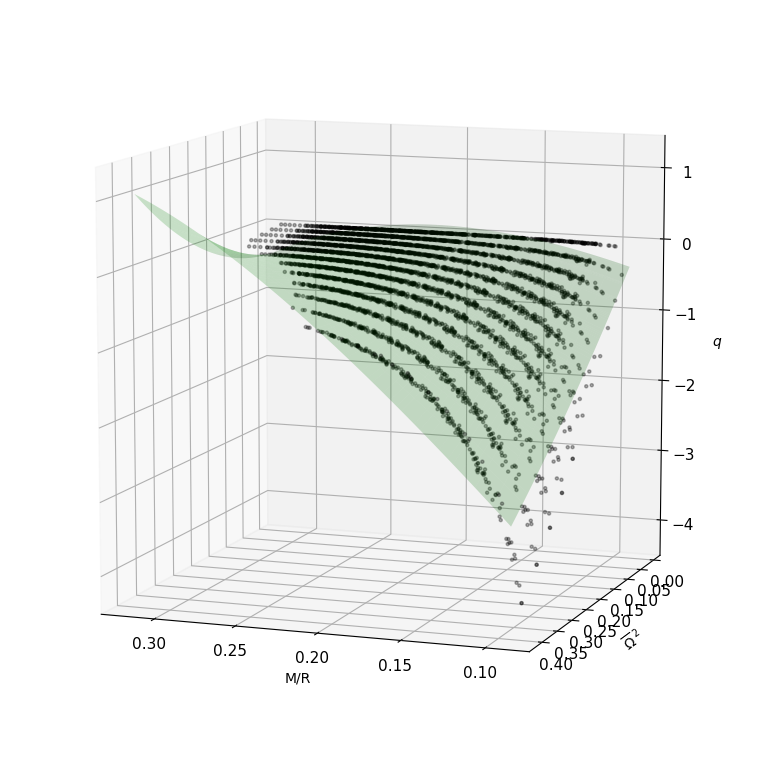

In [63]:
plot_3dquads(Eos_array, create_offset_fit([3,3]), [  1.32665917, -44.67836575, -99.78747946, -55.57943776,
       -65.89520583, -99.99794699, -34.41105467, -14.00185438,
        -3.76090478,  20.63940965], "Q_offset_fit")

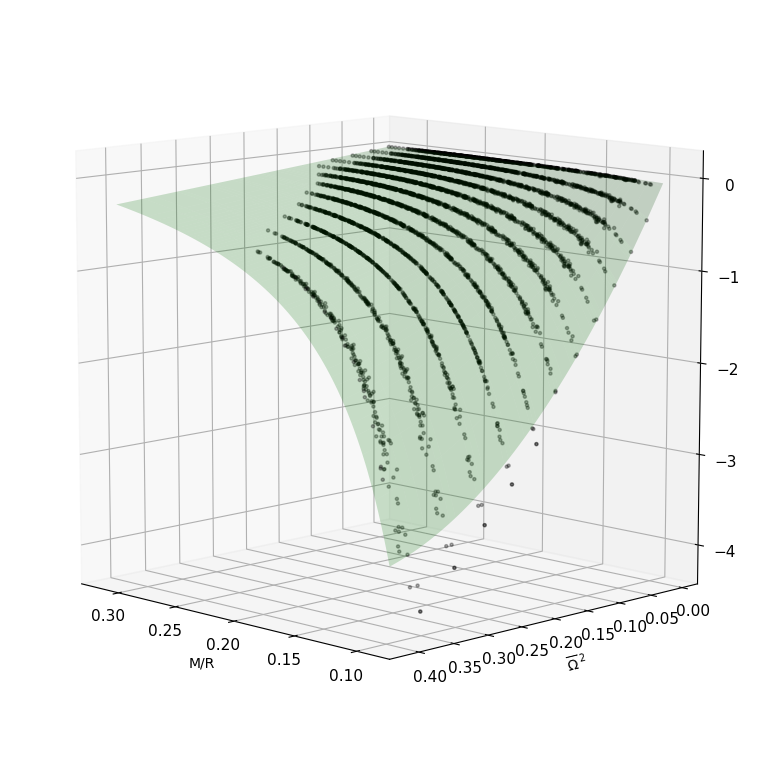

In [56]:
plot_3dquads(Eos_array, create_fit_func_q([3,3]), [ 1.27732812e-02, -6.73001462e-03,  6.10940044e-04,  8.89623481e-01,
       -1.17221274e-01, -1.20949781e-01,  1.42132492e-01, -6.09362383e-01,
        1.81638146e-01], "Q_3x3_fit")

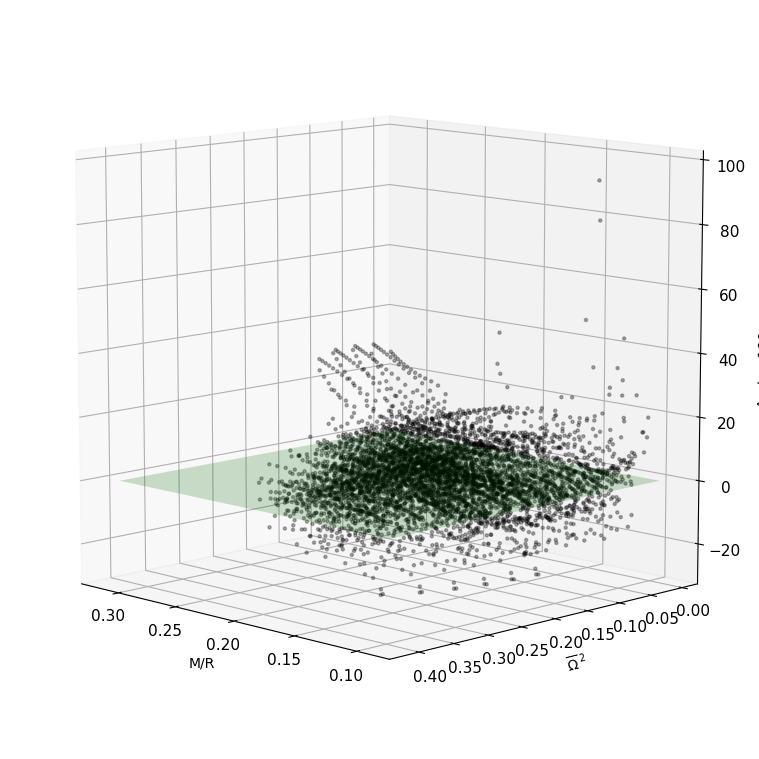

In [14]:
plot_3dquads(Eos_array, create_fit_func_q([3,3]), [ 1.27732812e-02, -6.73001462e-03,  6.10940044e-04,  8.89623481e-01,
       -1.17221274e-01, -1.20949781e-01,  1.42132492e-01, -6.09362383e-01,
        1.81638146e-01], "Q_3x3_fit_error", True)

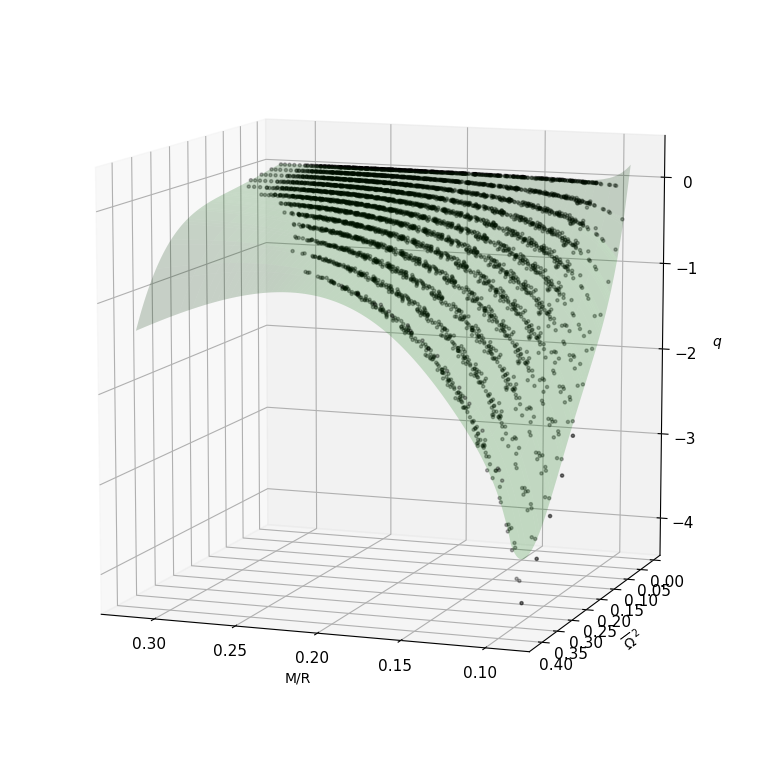

In [66]:
plot_3dquads(Eos_array, create_fit_func_q([5,5]), [ 4.37609962e-01, -3.38207137e-01,  9.38312602e-02, -1.11375115e-02,
        4.80919266e-04, -1.59758401e+01,  1.33258920e+01, -3.94224965e+00,
        4.60189824e-01, -2.01584060e-02,  5.40122705e+01, -6.01041770e+01,
        2.03301416e+01, -2.72240773e+00,  1.31881393e-01,  6.25889083e+01,
        7.50694205e+01, -4.37436260e+01,  7.11040840e+00, -3.82660242e-01,
       -6.33330037e+02,  2.01984196e+02, -4.19182089e+00, -3.65710930e+00,
        3.03919454e-01], "Q_5x5_fit")

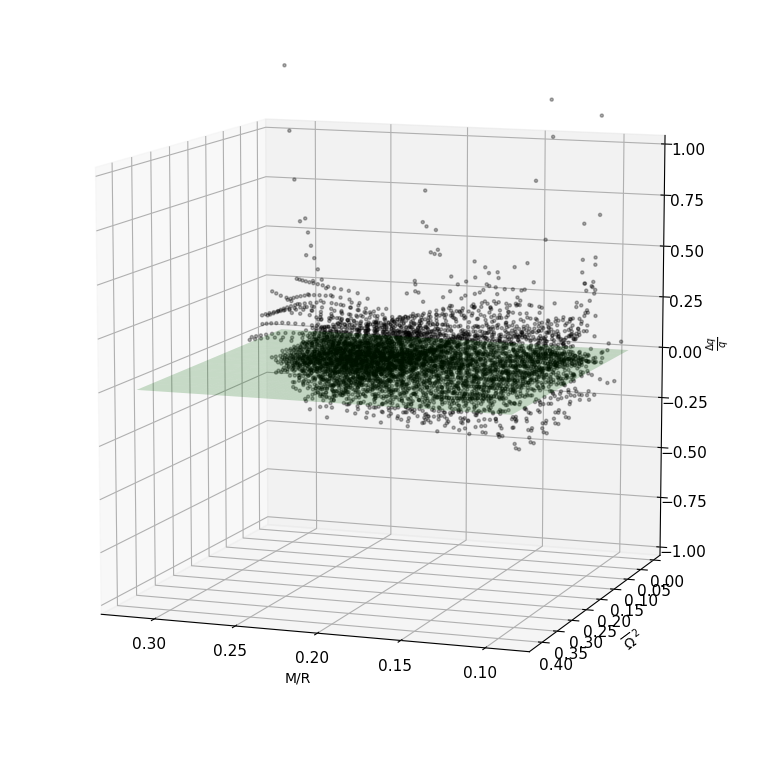

In [67]:
plot_3dquads(Eos_array, create_fit_func_q([5,5]), [ 4.37609962e-01, -3.38207137e-01,  9.38312602e-02, -1.11375115e-02,
        4.80919266e-04, -1.59758401e+01,  1.33258920e+01, -3.94224965e+00,
        4.60189824e-01, -2.01584060e-02,  5.40122705e+01, -6.01041770e+01,
        2.03301416e+01, -2.72240773e+00,  1.31881393e-01,  6.25889083e+01,
        7.50694205e+01, -4.37436260e+01,  7.11040840e+00, -3.82660242e-01,
       -6.33330037e+02,  2.01984196e+02, -4.19182089e+00, -3.65710930e+00,
        3.03919454e-01], "Q_5x5_fit_error", True)

------------------
Redshift fits

In [15]:
def old_formula(M_R, spins, params=[0.52, 1.15]):

    return 1/np.sqrt(1-2*M_R)*(1+spins**2*(params[1]*M_R**2+params[0]*M_R))-1

In [3]:
def create_fit_func_z(shapes):

    def general_fit(M_R, spins, params):

        # m is for MR
        # n is for Omega

        params = np.array(params).reshape(shapes)
        n = shapes[0]
        m = shapes[1]

        fit = np.ones(M_R.shape)
        for i in range(n):
            for j in range(m):
                #print(str(params[i,j])+" M/R^"+str(j+1)+" omega^"+str(2*(i+1)))
                fit += params[i,j]*M_R**(j+1)*spins**(2*(i+1))

        fit *= 1/np.sqrt(1-2*M_R)
        
        return fit-1

    return general_fit

In [ ]:
def residual_z(params, Eos_array, fit_func):

    M_R = np.empty([0])
    spins = np.empty([0])
    z_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            z_norm_p = (eos.z_rns(i_r)+1)*np.sqrt(1-2*mr)-1

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            z_norm = np.concatenate([z_norm, z_norm_p])

    z_emp = (fit_func(M_R, spins, params)+1)*np.sqrt(1-2*M_R)-1
    resid = np.sum((z_norm-z_emp)**2)

    return resid

In [ ]:
def diff_optimize_fit_z(Eos_array, shapes, bounds):

    lb = [bounds[0]]
    ub = [bounds[1]]
    lbs = lb*shapes[0]*shapes[1]
    #lbs[0] = 0.5439611
    #lbs[1] = 1.00764174
    ubs = ub*shapes[0]*shapes[1]
    #ubs[0] = 0.5439611
    #ubs[1] = 1.00764174
    bounds = Bounds(lbs, ubs)
    result = differential_evolution(residual_z, bounds, args=(Eos_real, create_fit_func_z(shapes)))

    coeffs = result.x.reshape(shapes)
    row_label = ['\u03A9^'+str(2*(i+1)) for i in range(shapes[0])]
    col_label = ['M/R^'+str(i+1) for i in range(shapes[1])]
    table = pd.DataFrame(coeffs, index=row_label, columns=col_label)
    print(table)

    print(residual_z(result.x, Eos_array, create_fit_func_z(shapes)))


    return result.x

In [9]:
def LSQ_fit_z(Eos_array, shapes):

    M_R = np.empty([0])
    spins = np.empty([0])
    z_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            z_norm_p = eos.z_rns(i_r)

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            z_norm = np.concatenate([z_norm, z_norm_p])

    n = shapes[0]
    m = shapes[1]

    X = ()
    for i in range(n):
        for j in range(m):
            X += ((M_R**(j+1)*spins**(2*i+1)),)
            #print("M/R^"+str(j+1)+" omega^"+str(2*(i+1)))
    X = np.array(X).transpose()

    xT = np.transpose(X)
    xTx = np.dot(xT, X)
    xTxinv = np.linalg.inv(xTx)
    C = np.dot(xTxinv, xT)
    coefs = np.dot(C, (1+z_norm)*np.sqrt(1-2*M_R)-1)

    return coefs

In [ ]:
# test LSQ for redshift
shape1 = [2,3]
coefs_lsq = LSQ_fit_z(Eos_array, shape1)
print(coefs_lsq)
residual_z(coefs_lsq, Eos_array, create_fit_func_z(shape1))

[ 0.1046173   0.52441174 -1.77779274  0.84619958 -2.92452016 16.42280969]


0.8645827754414045

In [ ]:
# this finds outliers in redshift

for eos in Eos_array:

    for i in range(N_spins):

        mr = eos.MR(i)
        js = eos.SPN(i)
        Zr = eos.z_rns(i)
        Ze = create_fit_func_z([2,3])(mr, js, [ 0.54446865,  1.14564791, -1.17334963, -0.08927648,  0.47259355, 1.93766783])

        bad_k = np.where(np.abs(Zr-Ze) > 0.0009)[0]

        if (bad_k.size > 0):

            for k in bad_k:
            
                print(eos.name)
                print('M = '+str(eos.data[k, i, 3]/Msun)+' Msun')
                print('R = '+str(eos.data[k, i, 2]/100000)+' km')
                print('\u03A9 = '+str(eos.data[k, i, 1]/(2*np.pi))+' Hz')
                print('r = '+str(r_ratios[i])+'\n')


APR
M = 2.168601992431744 Msun
R = 10.43553689143 km
Ω = 461.5203230893851 Hz
r = 0.979796613911713

KDE0v
M = 1.980385823678749 Msun
R = 9.85385782054 km
Ω = 801.2461275409757 Hz
r = 0.9462735797680495

Pol8
M = 2.2485927663090606 Msun
R = 11.03487786818 km
Ω = 811.7606776887344 Hz
r = 0.928488958588275



In [ ]:
diff_optimize_fit_z(Eos_array, [1,2], [-2,2])

        M/R^1     M/R^2
Ω^2  0.567581  0.874525


array([0.56758113, 0.87452545])

In [ ]:
diff_optimize_fit_z(Eos_array, [1,3], [-5,5])

       M/R^1     M/R^2     M/R^3
Ω^2  0.47294  1.898759 -2.622659


array([ 0.4729402 ,  1.89875872, -2.62265946])

In [ ]:
diff_optimize_fit_z(Eos_array, [2,2], [-2,2])

        M/R^1     M/R^2
Ω^2  0.596598  0.633946
Ω^4 -0.200577  1.463362


array([ 0.59659782,  0.63394646, -0.20057686,  1.46336219])

In [ ]:
diff_optimize_fit_z(Eos_array, [2,3], [-2,2])

        M/R^1     M/R^2     M/R^3
Ω^2  0.544469  1.145648 -1.173350
Ω^4 -0.089276  0.472594  1.937668


array([ 0.54446865,  1.14564791, -1.17334963, -0.08927648,  0.47259355,
        1.93766783])

In [ ]:
# with eos_real
diff_optimize_fit_z(Eos_real, [2,3], [-2,2])

        M/R^1     M/R^2     M/R^3
Ω^2  0.544199  1.141973 -1.173603
Ω^4 -0.088145  0.465426  1.987949
9.024407632435711e-05


array([ 0.54419854,  1.14197333, -1.17360259, -0.08814531,  0.46542641,
        1.98794945])

In [ ]:
diff_optimize_fit_z(Eos_array, [2,4], [-2,2])

        M/R^1     M/R^2     M/R^3     M/R^4
Ω^2  0.541895  1.169560 -1.274617  0.218256
Ω^4 -0.085546  0.483082  1.801846 -0.040830


array([ 0.54189483,  1.16955994, -1.27461703,  0.21825643, -0.08554595,
        0.48308175,  1.80184567, -0.04083036])

In [ ]:
diff_optimize_fit_z(Eos_array, [3,2], [-2,2])

        M/R^1     M/R^2
Ω^2  0.609495  0.579658
Ω^4 -0.321310  1.979435
Ω^6  0.243513 -1.050092


array([ 0.60949465,  0.57965814, -0.32130987,  1.9794347 ,  0.24351267,
       -1.05009229])

In [ ]:
diff_optimize_fit_z(Eos_array, [3,3], [-2,2])

        M/R^1     M/R^2     M/R^3
Ω^2  0.548169  1.117907 -1.119447
Ω^4 -0.128466  0.685841  1.769753
Ω^6  0.053304  0.045882 -1.402971


array([ 0.54816868,  1.11790668, -1.11944667, -0.12846555,  0.6858406 ,
        1.76975283,  0.05330385,  0.04588246, -1.4029711 ])

In [ ]:
diff_optimize_fit_z(Eos_array, [1,4], [-5,5])

        M/R^1     M/R^2     M/R^3    M/R^4
Ω^2  0.505429  1.363147  0.176368 -4.67717


array([ 0.5054287 ,  1.3631472 ,  0.1763677 , -4.67716992])

In [ ]:
def plot_3dredshifts(Eos_array, fit_func, params, savename, qfit=False, errors=False):
    # qfit=True will plot the Quasikerr redshift with 3x3 quadrupole fit

    if qfit:
        errors=True

    fig = plt.figure(figsize=plt.figaspect(0.9)*2)
    ax = fig.add_subplot(projection='3d')

    M_R = np.empty([0])
    spins = np.empty([0])
    z_norm = np.empty([0])

    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            spn = eos.SPN(i_r)
            z_norm_p = (eos.z_rns(i_r))#+1)*np.sqrt(1-2*mr)-1
            if qfit:
                z_emp_p = (1/eos.z_qfit(i_r))-1
            else:
                z_emp_p = (fit_func(mr, spn, params))#+1)*np.sqrt(1-2*mr)-1

            if errors:
                ax.scatter(mr, spn**2, (z_norm_p-z_emp_p)*100/z_norm_p, alpha=0.3, s=5)
            else:
                ax.scatter(mr, spn**2, z_norm_p, alpha=0.3, s=5)

            M_R = np.concatenate([M_R, mr])
            spins = np.concatenate([spins, spn])
            z_norm = np.concatenate([z_norm, z_norm_p])

    M_R_mesh, spins_mesh = np.meshgrid(np.sort(M_R), np.sort(spins))
    z_emp = (fit_func(M_R_mesh, spins_mesh, params))#+1)*np.sqrt(1-2*M_R_mesh)-1

    if not errors:
        ax.plot_surface(M_R_mesh, spins_mesh**2, z_emp, color='green', alpha=0.2)
    else:
        ax.plot_surface(M_R_mesh, spins_mesh**2, np.zeros(M_R_mesh.shape), color='green', alpha=0.2)
    ax.view_init(elev=15, azim=-110)
    ax.set_box_aspect(aspect=(1, 1, 1))
    font=11
    ax.tick_params(labelsize=font, pad=1)
    ax.tick_params(axis='z', labelsize=font, pad=4)
    ax.set_xlabel("M/R", labelpad=2)
    ax.set_ylabel("$\overline{\Omega}^{\ 2}$", labelpad=2)
    if errors:
        ax.set_zlabel(r"${\Delta z \ }/ \ z_0 \cdot 100$", labelpad=8)
    else:
        ax.set_zlabel("$z_{0}$", labelpad=8)

    plt.savefig(savename+".png", dpi=390)

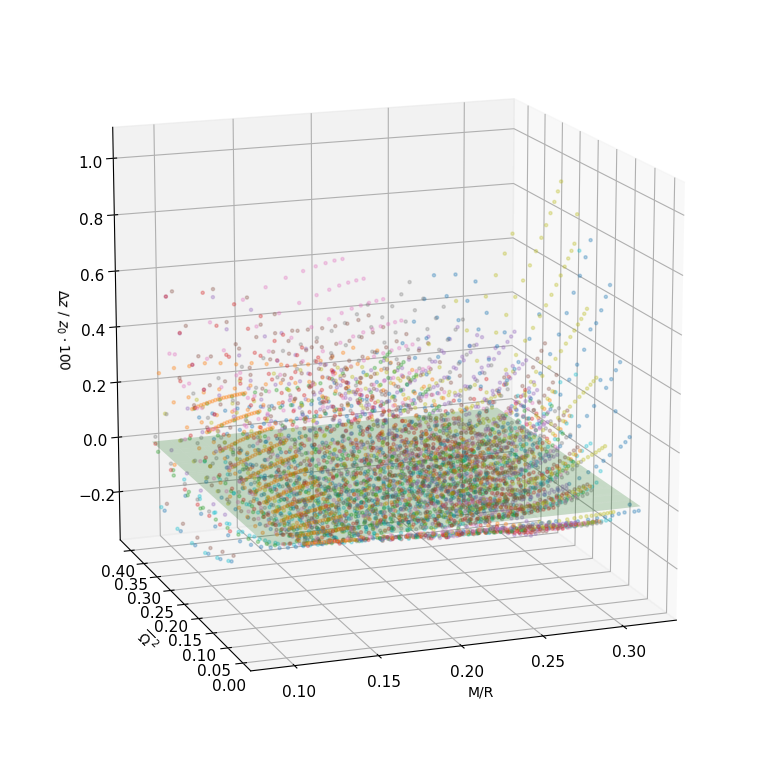

In [8]:
plot_3dredshifts(Eos_array, create_fit_func_z([2,2]), [ 0.59659782,  0.63394646, -0.20057686,  1.46336219], "Z_2x2_Q_error", qfit=True)

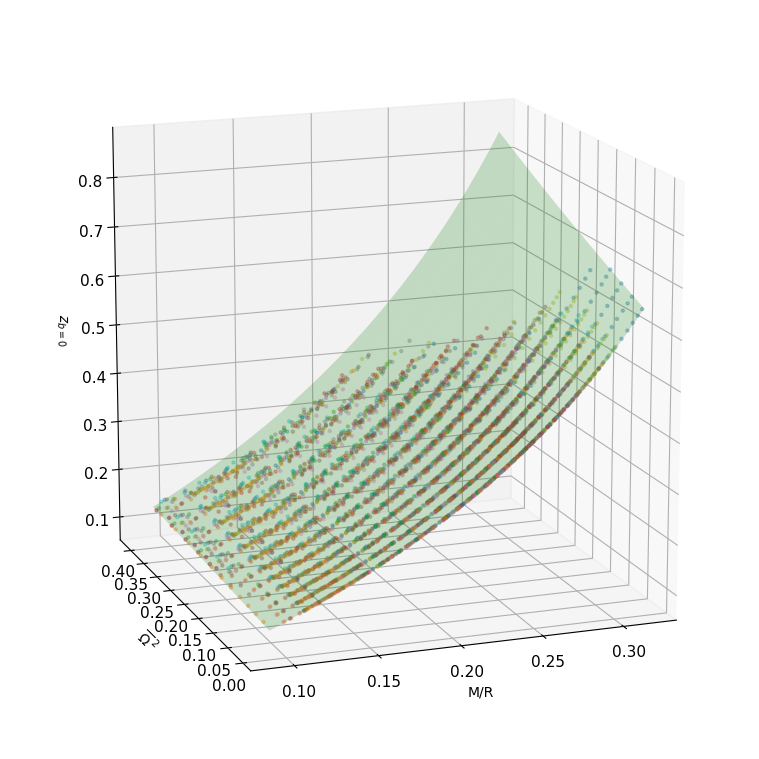

In [85]:
plot_3dredshifts(Eos_array, create_fit_func_z([2,2]), [ 0.59659782,  0.63394646, -0.20057686,  1.46336219], "Z_2x2_fit")

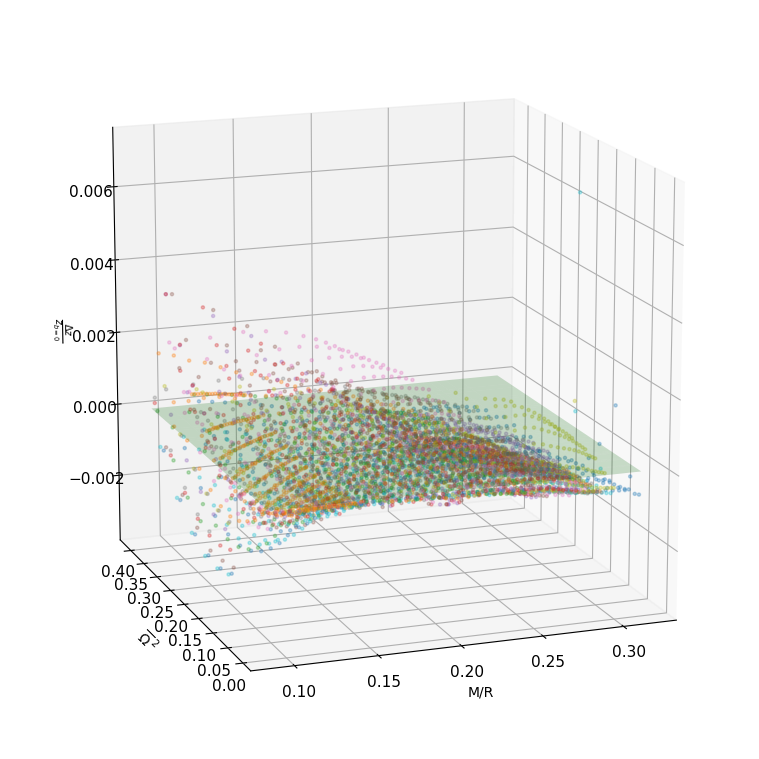

In [86]:
plot_3dredshifts(Eos_array, create_fit_func_z([2,2]), [ 0.59659782,  0.63394646, -0.20057686,  1.46336219], "Z_2x2_fit_error", errors=True)

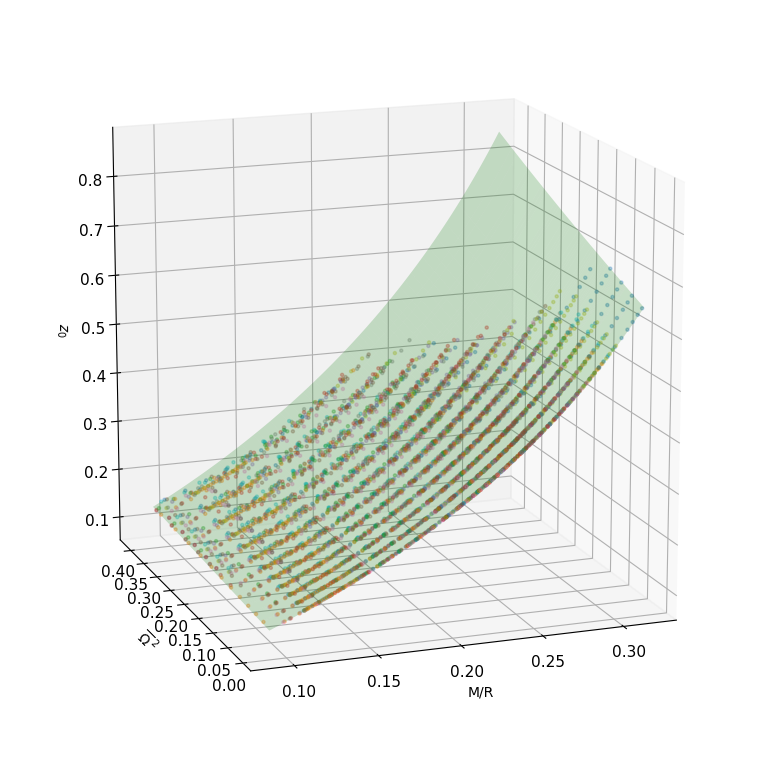

In [34]:
plot_3dredshifts(Eos_array, create_fit_func_z([2,3]), [ 0.54446865,  1.14564791, -1.17334963, -0.08927648,  0.47259355,
        1.93766783], "Z_2x3_fit")

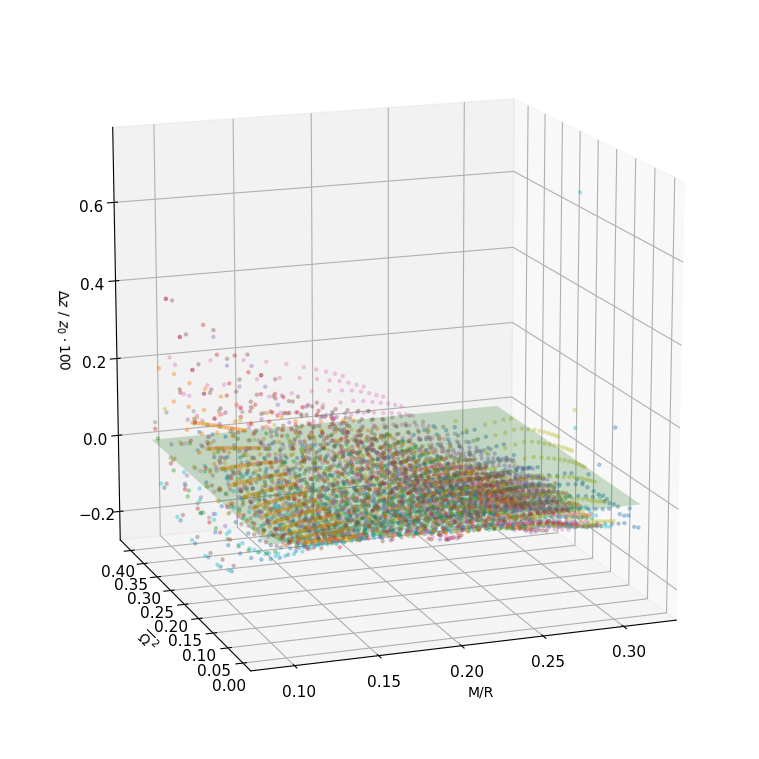

In [44]:
plot_3dredshifts(Eos_array, create_fit_func_z([2,3]), [ 0.54446865,  1.14564791, -1.17334963, -0.08927648,  0.47259355,
        1.93766783], "Z_2x3_fit_error", errors=True)

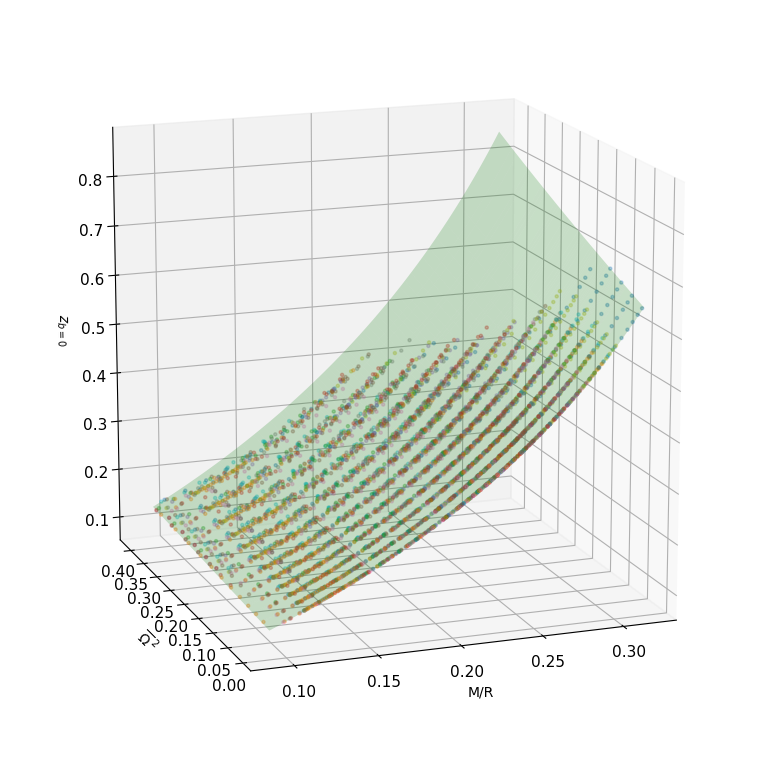

In [89]:
plot_3dredshifts(Eos_array, create_fit_func_z([3,3]), [ 0.53944633,  1.17920773, -1.20619338, -0.06465179,  0.34301731,
        1.874211  , -0.02449818,  0.08461446,  0.38444905], "Z_3x3_fit")

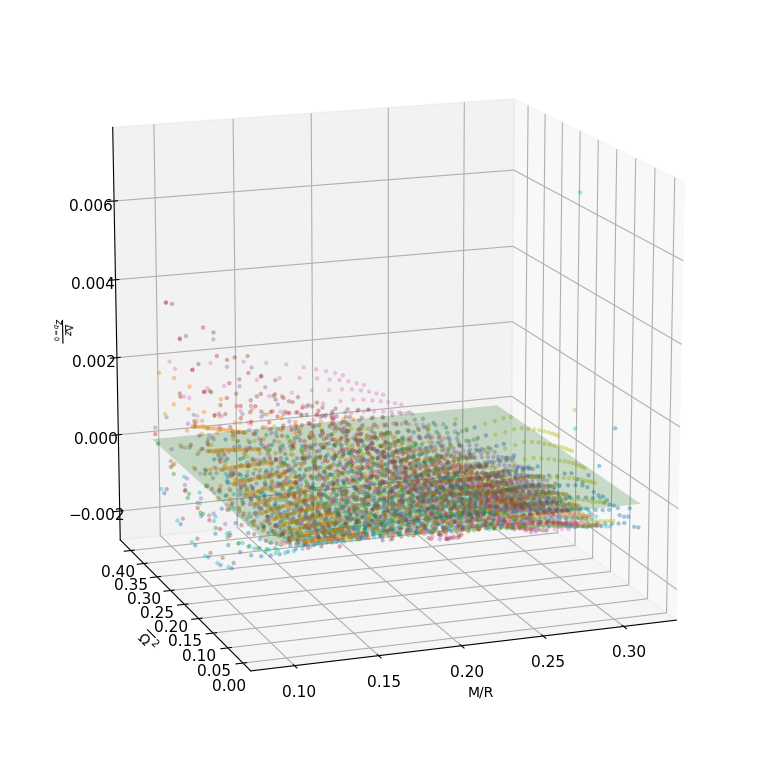

In [90]:
plot_3dredshifts(Eos_array, create_fit_func_z([3,3]), [ 0.53944633,  1.17920773, -1.20619338, -0.06465179,  0.34301731,
        1.874211  , -0.02449818,  0.08461446,  0.38444905], "Z_3x3_fit_error", errors=True)

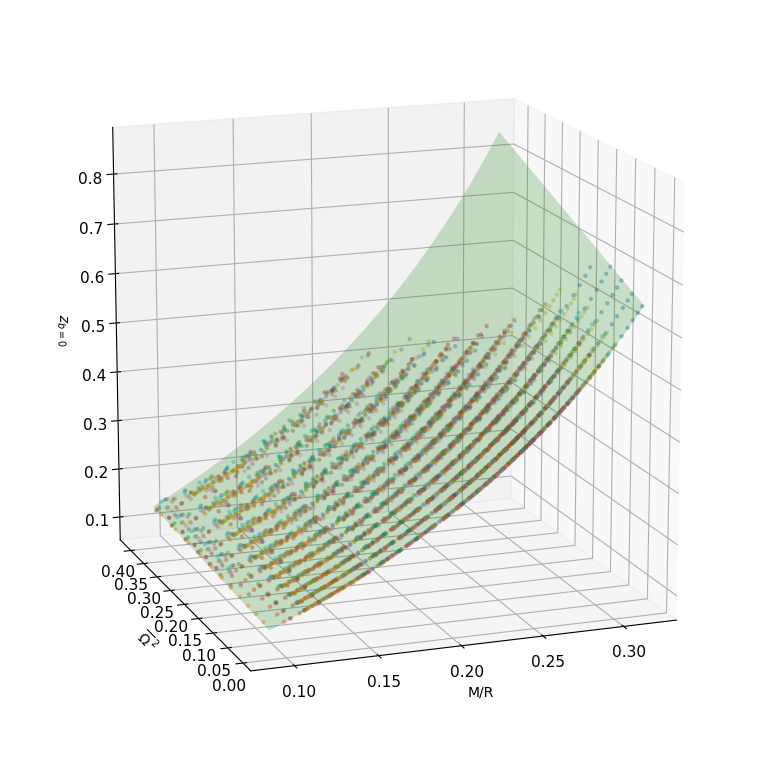

In [91]:
plot_3dredshifts(Eos_array, create_fit_func_z([1,2]), [0.53839792, 1.05210374], "Z_1x2_fit")

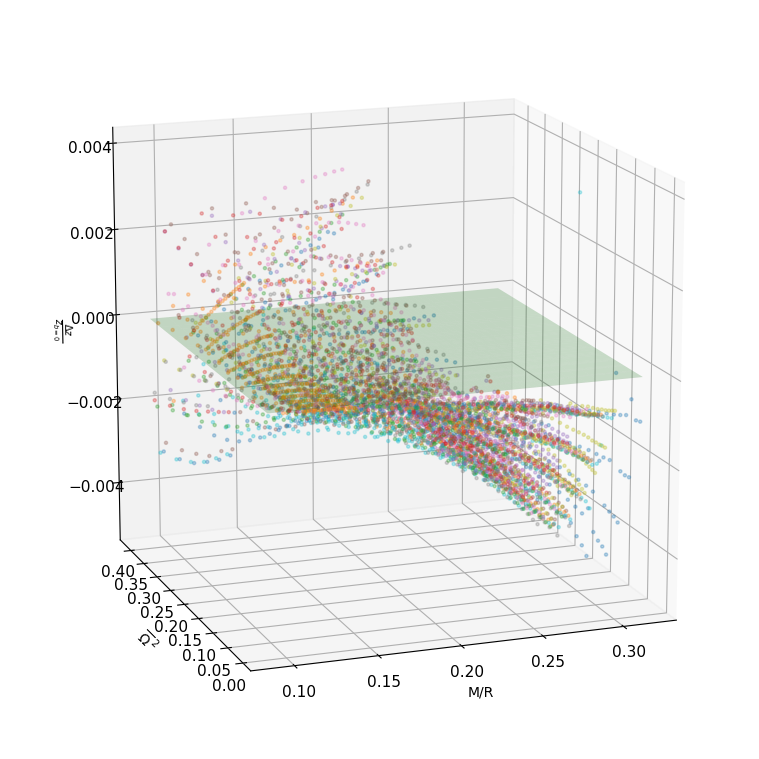

In [92]:
plot_3dredshifts(Eos_array, create_fit_func_z([1,2]), [0.53839792, 1.05210374], "Z_1x2_fit_error", errors=True)

Plot redshifts as a function of mu (comment out different lines to change plot)

In [7]:
def plot_ZvsMu(eos, e_c, r):

    sub.run('make quasik')
    sub.run('./quasik.exe -f "compose/eos'+eos+'" -e '+e_c+' -r '+r+' -m 1', capture_output=True)
    #print('./quasik.exe -f "compose/eos'+eos+'" -e '+e_c+' -r '+r+' -m 1')

    redshifts = np.array(pd.read_csv('redshift.csv'))

    mu = redshifts[:,0]

    # RNS
    z_rns_0 = redshifts[:,1]
    z_rns_max = redshifts[:,2]
    z_rns_min = redshifts[:,3]
    # e^-(gamma+rho)/2
    z_grav = redshifts[:,5]

    # Schwarzschild
    z_sch = redshifts[:,4]

    # Oblate Schwarzschild
    z_os_0 = redshifts[:,6]
    z_os_max = redshifts[:,7]
    z_os_min = redshifts[:,8]
    gamma = redshifts[:,9]

    # Kerr, Quasikerr with exact q
    z_ker = 1/redshifts[:,10]-1
    z_quk = 1/redshifts[:,11]-1

    z_quk_bad = 1/redshifts[:,12]-1

    # Quasikerr with 3x3 fit q
    z_quk_fit = 1/redshifts[:,13]-1

    star_data = np.loadtxt('star.csv', delimiter=',')
    MR = star_data[4]
    SPN = star_data[5]
    z_emp = create_fit_func_z([2,3])(np.array([MR]), np.array([SPN]), [ 0.54446865,  1.14564791, -1.17334963, -0.08927648,  0.47259355,
        1.93766783])[0]

    fig, ax = plt.subplots()
    ax.plot(mu, z_rns_0, c='k', alpha=0.3, lw=3, label='RNS')
    ax.plot(mu, z_emp*np.ones(mu.shape), c='y', alpha=0.3, lw=3, label='approximation')
    #ax.plot(mu, z_sch, c='m', alpha=0.7, label='Schwarzschild')
    #ax.plot(mu, z_grav, c='c', alpha=0.7, label='$ RNS \ g_{tt}$')
    ax.plot(mu[:-1], z_os_0[:-1], c='b', alpha=0.7, label='Oblate Schwarzschild')
    #ax.plot(mu, z_schv, c='brown', alpha=0.7, label='$Sch/\gamma$')
    ax.plot(mu, z_ker, c='g', alpha=0.7, label='Kerr')
    ax.plot(mu, z_quk, c='r', alpha=1, lw=2, linestyle=':', label='Quasikerr')
    ax.plot(mu, z_quk_fit, c='m', alpha=1, lw=2, linestyle=':', label='QK with q fit')
    ax.plot(mu, z_quk_bad, c='lime', alpha=1, lw=2, linestyle=':', label='QK with Bauböck q')
    plt.xlabel(r"$\cos\theta$")
    plt.ylabel('z')
    #ax.set_ylim(0, 0.3)
    ax.legend(loc='best')
    plt.savefig(eos+'_'+e_c+'_'+r+'_a.jpeg', dpi=150)

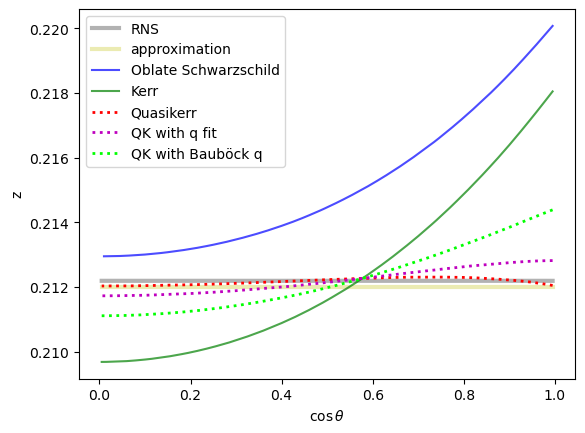

In [10]:
plot_ZvsMu('CMF1', '6e14', '0.9')

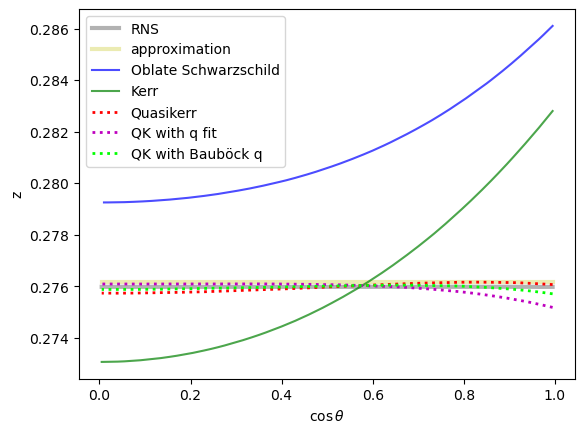

In [8]:
plot_ZvsMu('FPS', ' 1.209e15 ', '0.898196')

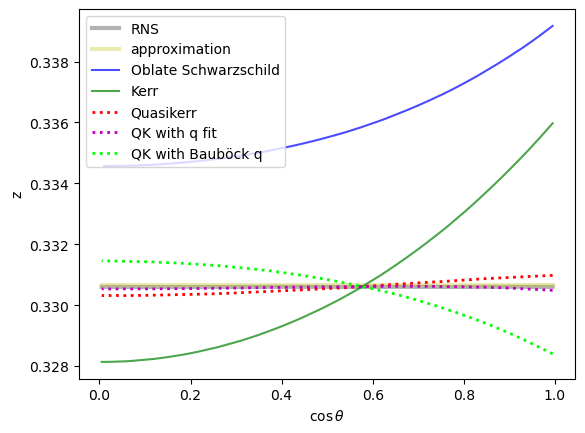

In [9]:
plot_ZvsMu('A', '1.76e15', '0.933')

Histograms to show distribution of data

In [7]:
def histograms(Eos_array):

    M_R = np.empty([0])
    M = np.empty([0])
    F = np.empty([0])


    for i_r in range(N_spins):
        for i_s in range(Eos_array.size):

            eos = Eos_array[i_s]

            mr = eos.MR(i_r)
            m = eos.M(i_r)
            f = eos.f(i_r)

            M_R = np.concatenate([M_R, mr])
            M = np.concatenate([M, m])
            F = np.concatenate([F, f])


    plt.figure()
    plt.hist(M_R, 30, rwidth=0.8)
    plt.xlabel("M/R")

    plt.figure()
    plt.hist(M, 30, rwidth=0.8)
    plt.xlabel("$M/M_\odot$")

    plt.figure()
    plt.hist(F, 30, rwidth=0.8)
    plt.xlabel("f (Hz)")

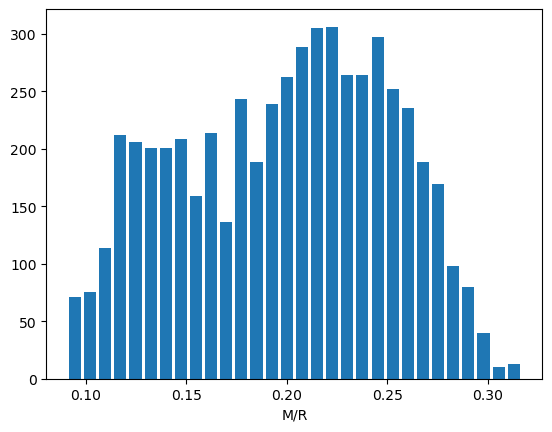

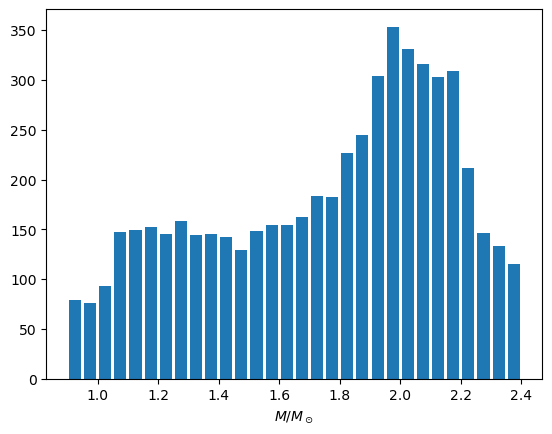

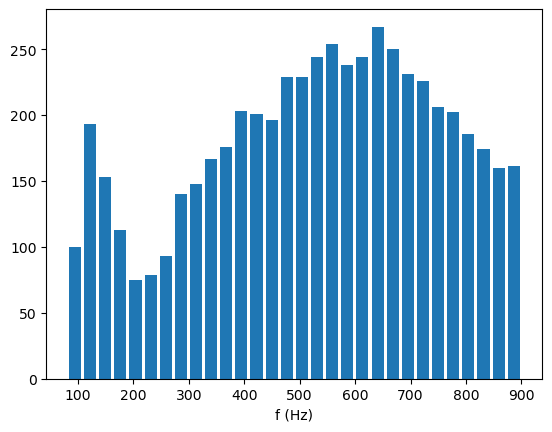

In [8]:
histograms(Eos_array)

Recreate datasets

In [ ]:
def create_dataset(i):
    
    eos = eos_names[i]
    e_min = min_dens[i]
    e_max = max_dens[i]
    ratios = r_ratios
    densities = np.linspace(e_min, e_max, N_dens)

    star_data = np.zeros([N_dens, N_spins, 12])
    i_r=0
    t_0 = time.time()
    for r in ratios:
        i_e = 0
        for e in densities:
            string = 'quasik.exe -f "compose/eos' + eos + '" -e ' + "{:e}".format(e).replace('+', '') + ' -r ' + str(r)
            sub.run(string)
            output = np.loadtxt('star.csv', delimiter=',')
            star_data[i_e,i_r,:] = output
            print(eos+'  %i, %i ' % (i_r+1, i_e+1), end='\r')
            i_e += 1
        i_r += 1
    np.save('star_data_'+eos, star_data)
    t_f = time.time()
    t_min = round((t_f-t_0)/60, 2)
    print(eos+' done in '+str(t_min)+' minutes')
    return

In [5]:
for i in range(eos_names.size):
    try:
        create_dataset(i)
    except ValueError:
        print(str(eos_names[i])+' failed due to ValueError')
    except TypeError:
        print(str(eos_names[i])+' failed due to TypeError')
    except Exception:
        print(str(eos_names[i])+' failed due to Exception')

APR done in 7.15 minutes
BBB done in 7.63 minutes
BLC done in 6.6 minutes
CMF1 done in 7.02 minutes
CMF1H done in 7.43 minutes
CMF2 done in 7.15 minutes
D1MStar done in 7.29 minutes
DDMEX done in 5.64 minutes
GDFMII done in 6.05 minutes
KDE0v done in 8.54 minutes
M3 done in 7.19 minutes
NL3 done in 5.51 minutes
PCSB2 done in 5.91 minutes
PKDD done in 6.24 minutes
QHC21A done in 6.27 minutes
QMCRMF3 done in 6.34 minutes
Rs done in 7.77 minutes
SK255 done in 8.31 minutes
Ska done in 7.41 minutes
TW done in 7.97 minutes
Pol0 done in 6.93 minutes
Pol1 done in 6.63 minutes
Pol2 done in 7.07 minutes
Pol3 done in 7.92 minutes
Pol4 done in 7.71 minutes
Pol5 done in 7.35 minutes
Pol6 done in 7.04 minutes
Pol7 done in 7.77 minutes
Pol8 done in 6.42 minutes
Pol9 done in 7.62 minutes


Redshift maps

In [12]:
incl = 20
obl = 0.9
sub.run('make quasik')
sub.run('./quasik.exe -f "compose/eosAPR" -e 9e14 -r ' + str(obl) + ' -i ' + str(incl) + ' -p 15 -m 1', capture_output=True)

CompletedProcess(args='./quasik.exe -f "compose/eosAPR" -e 9e14 -r 0.9 -i 20 -p 15 -m 1', returncode=0, stdout=b'EOS file: compose/eosAPR, Grid size = MDIVxSDIV = 151x301\r\n\r\ne_center = 0.9e15 g/cm^3\r\nr_ratio  = 0.9\r\nMass     = 1.26521 MSUN\r\nM/R      = 0.156199 \r\nR_e      = 11.9646 km\r\nSpin     = 615.633 Hz\r\nj = a/M  = J/M^2 = 0.331195 \r\n\r\nQuadrupole: Laarakkers and Poisson \r\nQuadrupole = -5.32788e+43 g cm^2 \r\nqscale = -0.606151 \r\nmscale = -0.620183 \r\nLP formula: q = -0.471669 \r\nQuasiKerr dimensionless quadrupole parameter: epsilon = 0.496461 \r\n\r\nComparison of QuasiKerr Metric with numerical RNS metric\r\nOmega = 3868.133772, Omega_K = 9877.481915\r\nMaking redshift map\r\nMap done\r\n', stderr=b'')

In [13]:
MDIV = 150
cols = 6

mapdata = np.array(pd.read_csv('zmap.csv', header=None)).reshape([2*MDIV, MDIV, cols])
theta = np.arccos(mapdata[:,:,0])
phi = mapdata[:,:,1]
zos = mapdata[:,:,2]
zrns = mapdata[:,:,3]
zqk = mapdata[:,:,4]
zqkb = mapdata[:,:,5]

cmap = plt.cm.coolwarm
cmap.set_bad(color='w')

In [8]:
def zmap_2d(zmap, vmin=None, vmax=None):

    z_mask = np.ma.masked_where(zmap == 0, zmap).transpose()

    if vmin==None:
        vmin = zmap.min()
    if vmax==None:
        vmax = zmap.max()

    plt.figure()
    plt.pcolormesh(phi.transpose(), theta.transpose(), z_mask, cmap=cmap, vmin=vmin, vmax=vmax)
    plt.errorbar([np.pi/2, -np.pi/2], [np.pi/2, np.pi/2], xerr=np.pi/2, yerr=np.pi/2, c='k', lw=0.4)
    plt.gca().invert_yaxis()
    plt.ylabel(r"$\theta$")
    plt.xlabel(r"$\phi$")
    plt.colorbar(label="z")
    plt.savefig("out.png", dpi=390)

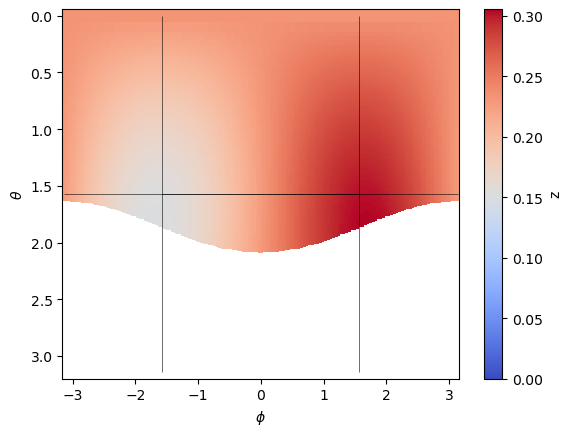

In [14]:
zmap_2d(zos)

In [10]:
def zmap_3d(zmap, vmin=None, vmax=None):

    z_mask = np.ma.masked_where(zmap == 0, zmap)

    if vmin==None:
        vmin = zmap.min()
    if vmax==None:
        vmax = zmap.max()

    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    z_mask = norm(z_mask)

    x = np.sin(theta) * np.cos(phi)
    y = np.sin(theta) * np.sin(phi)
    z = np.cos(theta)

    fig = plt.figure(figsize=plt.figaspect(obl)*2)
    ax = fig.add_subplot(projection='3d')
    ax.plot_surface(x, y, z, rcount=2*MDIV+1, ccount=2*MDIV+1, facecolors=cmap(z_mask), shade=False)
    ax.scatter([0],[0],[1.07],c='g',s=5)
    ax.view_init(elev=90-incl, azim=0)
    ax.axis("off")
    mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    mappable.set_array(z_mask)
    fig.colorbar(mappable, shrink=0.5, ax=ax)
    ax.set_box_aspect(aspect=(1, 1, obl))
    ax.set_xlim([-1,1])
    ax.set_ylim([-1,1])
    ax.set_zlim([-1,1])
    plt.xlabel("x")
    plt.ylabel("y")
    plt.savefig("out2.png", dpi=390)

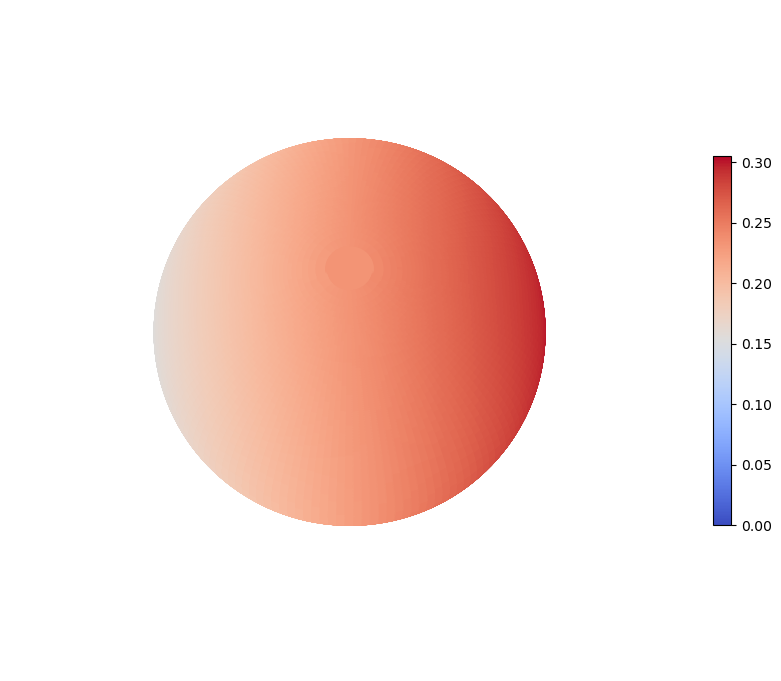

In [15]:
zmap_3d(zos)